# Libraries and loading data

In [1]:
import MAS_library as MASL
import numpy as np
import scipy
import h5py as h5
import matplotlib.pyplot as plt
import readgadget
from collections import defaultdict
from mpi4py import MPI
import random
import psutil
import os
import pandas as pd
import pickle

def nested_dict(n, type):
    """
    This function creates a nested dictionary with a specified depth and default value type.

    Parameters:
        n (int): an integer representing the depth of the nested dictionary.
        type: the default value type for the nested dictionary.

    Returns:
        A nested dictionary with a depth of 'n' and default values of the specified type.
    """
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
    
data_load = nested_dict(5, list)

In [13]:
data_pop1=[]
data_pop2=[]

column_names = ['simulation','n_grid', 'dx','number_smaples', 'alpha_p1', 'alpha_p2', 'std_alpha_p1', 'std_alpha_p2', 'num_subbox']
data_alpha = pd.DataFrame(columns=column_names)
for number_smaples in [5, 25, 50, 100 , 250, 500, 1000]:  # How many sub-boxes
    for sim_size in ['L_512_N_256']:
        boxsize=512.0;
        mass_limit = 1.5*1.e13;
        for sim in ['Mn_0d6_nu_pcls','lcdm']:
            for ngrid in range(1,40,2): 
            # for ngrid in range(7,8,1): 

                if(number_smaples>ngrid*ngrid*ngrid):
                    number_smaples_tmp = ngrid*ngrid*ngrid;
                    print("\033[31m chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:"+str(number_smaples)+"\033[0m")
                else:
                    number_smaples_tmp = number_smaples;
                file_path = './save_data_run/data_ngrid_'+str(ngrid)+'_sim_'+sim+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle';
                if os.path.exists(file_path):
                    with open(file_path,'rb') as handle:
                        df = pickle.load(handle)
                        if not df['bulk_vel_cdm_i'].empty:
                            vb = np.array([np.array(x) for x in df['bulk_vel_cdm_i']])[0]# The zeroth component picks the velocities the first component is the error!
                            vb_dot_vb = np.einsum('ij,ij->i', vb, vb) # dot product of v_bulk vectors with itself
                            avg_vb_dot_vb = np.average(vb_dot_vb) # since there are many particles the weights for vb_dot_vb are more or less close to 1
                            std_vb_dot_vb = np.sqrt(np.average((vb_dot_vb - np.average(vb_dot_vb))**2))
                            # print()
                            #### population 1
                            weight = np.array([np.array(x) for x in df['vp1.v_b(halos)']])[:,2] # number of halos in each sub-box
                            vector_vp1_dot_vb = np.array([np.array(x) for x in df['vp1.v_b(halos)']])[:,0]
                            avg_vp1_dot_vb = np.average(vector_vp1_dot_vb, weights=weight, axis=0)
                            std_vp1_dot_vb=  np.average((vector_vp1_dot_vb - np.average(vector_vp1_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

                            #### population 2
                            weight = np.array([np.array(x) for x in df['vp2.v_b(halos)']])[:,2] # number of halos in each sub-box
                            vector_vp2_dot_vb = np.array([np.array(x) for x in df['vp2.v_b(halos)']])[:,0]
                            avg_vp2_dot_vb = np.average(vector_vp2_dot_vb, weights=weight, axis=0)
                            std_vp2_dot_vb=  np.average((vector_vp2_dot_vb - np.average(vector_vp2_dot_vb, weights=weight))**2, weights=weight) # This computes the standard deviation considering the weights!

                            # computing alpha_p1, alpha_p2
                            # std_alpha_p1 = (mu/nu)^2 * (std_mu^2/mu^2 + std_nu^2/nu^2) he ratio of two averages, alpha = mu/nu, can be thought of as the result of dividing two normal distributions. The variance of the ratio of two random variables is given by:
                            # Var(alpha) = (mu/nu)^2 * (Var(mu)/mu^2 + Var(nu)/nu^2 - 2 * Cov(mu,nu)/(mu*nu))
                            alpha_p1 = avg_vp1_dot_vb/avg_vb_dot_vb
                            std_alpha_p1 = (avg_vp1_dot_vb/avg_vb_dot_vb)**2 * (std_vp1_dot_vb**2/avg_vp1_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
                            # std_alpha_p1 = np.sqrt(var_alpha_p1); 
                            # print(number_smaples, alpha_p1, std_alpha_p2)

                            # pop2:
                            alpha_p2 = avg_vp2_dot_vb/avg_vb_dot_vb
                            var_alpha_p2 = (avg_vp2_dot_vb/avg_vb_dot_vb)**2 * (std_vp2_dot_vb**2/avg_vp2_dot_vb**2 + std_vb_dot_vb**2/avg_vb_dot_vb**2)
                            std_alpha_p2 = np.sqrt(var_alpha_p2); 
                            ### saving data:
                            dx = boxsize/ngrid;
                            data_pop1.append([dx,alpha_p1, std_alpha_p1, np.shape(vb)[0]])
                            data_pop2.append([dx,alpha_p2, std_alpha_p2, np.shape(vb)[0]]) # np.shape(vb)[0] shows the number of sub-boxes have been analyzed!
                            data_saved = {
                                    'simulation':sim,
                                    'ngrid': ngrid,
                                    'dx': dx,
                                    'number_smaples': number_smaples,
                                    'alpha_p1': alpha_p1,
                                    'alpha_p2': alpha_p2,
                                    'std_alpha_p1':std_alpha_p1,
                                    'std_alpha_p2':std_alpha_p2,
                                    'num_subbox':np.shape(vb)[0]
                                    }
                            data_alpha = data_alpha.append(data_saved, ignore_index=True)
                            
                        else:
                            print("\033[31m number sample: "+str(number_smaples)+", for ngrid: "+str(ngrid)+" is empty"+"\033[0m")
                    
                else:
                    print("\033[31m  Warning: File"+ file_path+" does not exist. \033[0m")
                    
                    


 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:5
 number sample: 5, for ngrid: 19 is empty
 number sample: 5, for ngrid: 21 is empty
 number sample: 5, for ngrid: 23 is empty
 number sample: 5, for ngrid: 25 is empty
 number sample: 5, for ngrid: 27 is empty
 number sample: 5, for ngrid: 33 is empty
 number sample: 5, for ngrid: 35 is empty
 number sample: 5, for ngrid: 37 is empty
 number sample: 5, for ngrid: 39 is empty
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:5
 number sample: 5, for ngrid: 23 is empty
 number sample: 5, for ngrid: 31 is empty
 number sample: 5, for ngrid: 33 is empty
 number sample: 5, for ngrid: 35 is empty
 number sample: 5, for ngrid: 37 is empty
 chosen number of samples is larger than total sub-boxes! number of sub-boxes changed to:25
 number sample: 25, for ngrid: 35 is empty
 number sample: 25, for ngrid: 39 is empty
 chosen number of samples is larger than total sub-b

In [38]:
data_alpha

,simulation,n_grid,dx,number_smaples,alpha_p1,alpha_p2,std_alpha_p1,std_alpha_p2,num_subbox,ngrid
0,Mn_0d6_nu_pcls,NaN,512.000000,5,-0.000005,0.000003,0.000005,0.000003,2,1.0
1,Mn_0d6_nu_pcls,NaN,170.666667,5,0.207978,0.209316,957.731201,907.669096,2,3.0
2,Mn_0d6_nu_pcls,NaN,102.400000,5,0.483524,0.393329,4005.400563,3099.137949,2,5.0
3,Mn_0d6_nu_pcls,NaN,73.142857,5,0.571942,0.687728,922.381971,6643.779620,2,7.0
4,Mn_0d6_nu_pcls,NaN,56.888889,5,0.624309,0.388659,28644.860429,1632.138325,2,9.0
...,...,...,...,...,...,...,...,...,...,...
255,lcdm,NaN,16.516129,1000,0.323868,0.296071,41525.776118,31157.029399,2,31.0
256,lcdm,NaN,15.515152,1000,1.189143,1.270511,195433.053245,185768.296509,2,33.0
257,lcdm,NaN,14.628571,1000,0.783159,0.789015,108246.095365,85075.941479,2,35.0
258,lcdm,NaN,13.837838,1000,0.389392,0.588813,43135.715888,75421.262750,2,37.0


# PLot

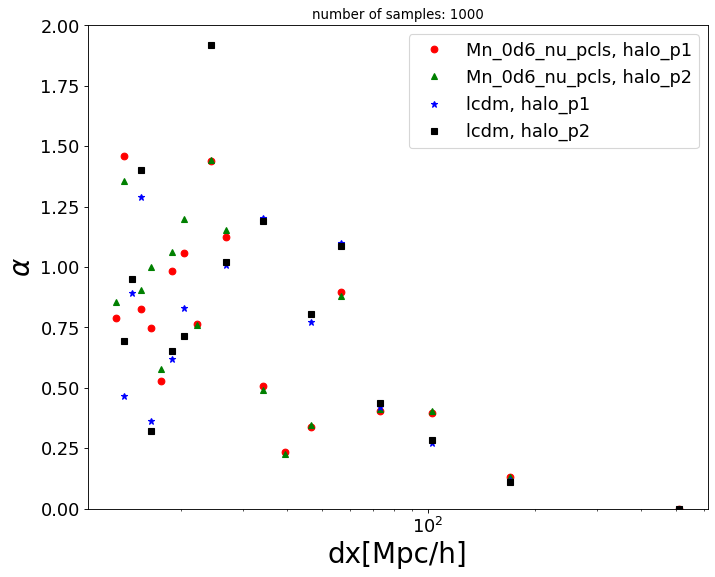

In [14]:




set_points = ["ro","b*"]

set_points2 = ["g^","ks"]
for number_smaples in [1000]:
    from matplotlib.pyplot import figure
    figure(figsize=(10, 8), dpi=80)
    l = 0 
    for sim in ['Mn_0d6_nu_pcls','lcdm']:
        con1 = (data_alpha['simulation']==sim)
        con2 = (data_alpha['number_smaples']==number_smaples)
        x_p1 = data_alpha[con1 & con2]['dx']
        alpha_p1 = data_alpha[con1 & con2]['alpha_p1']
        std_alpha_p1 = data_alpha[con1 & con2]['std_alpha_p1']
        # print(std_alpha_p1)
        plt.plot(x_p1, alpha_p1, set_points[l], label=sim+", halo_p1")
        # plt.errorbar(x_p1, alpha_p1, yerr=std_alpha_p1, fmt='o')
        
        x_p2 = data_alpha[con1 & con2]['dx']
        alpha_p2 = data_alpha[con1 & con2]['alpha_p2']
        plt.plot(x_p2, alpha_p2, set_points2[l], label=sim+", halo_p2")

        plt.title("number of samples: "+ str(number_smaples))
        plt.rcParams['xtick.labelsize']=16
        plt.rcParams['ytick.labelsize']=16
        plt.xlabel("dx[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha$",fontsize=25)
        plt.legend(fontsize=16)
        plt.xscale('log')
        plt.ylim(0,2)
        # plt.yscale('log')
        data_alpha['number_smaples']==500
        l=l+1

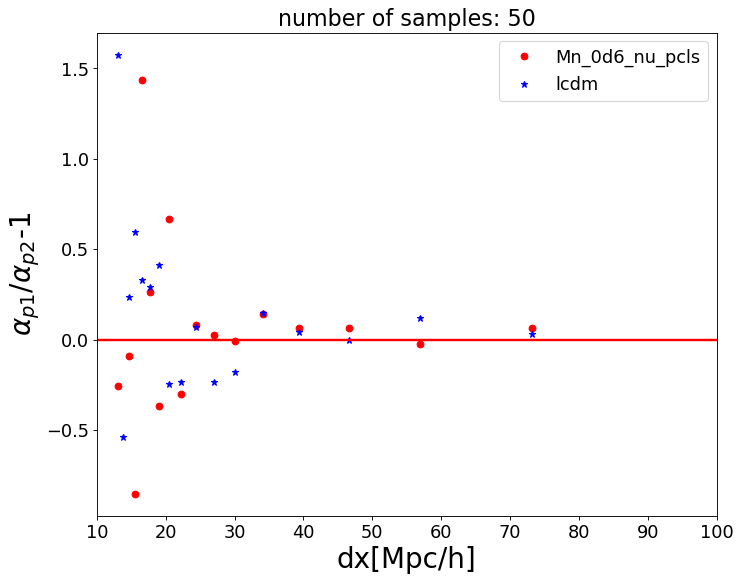

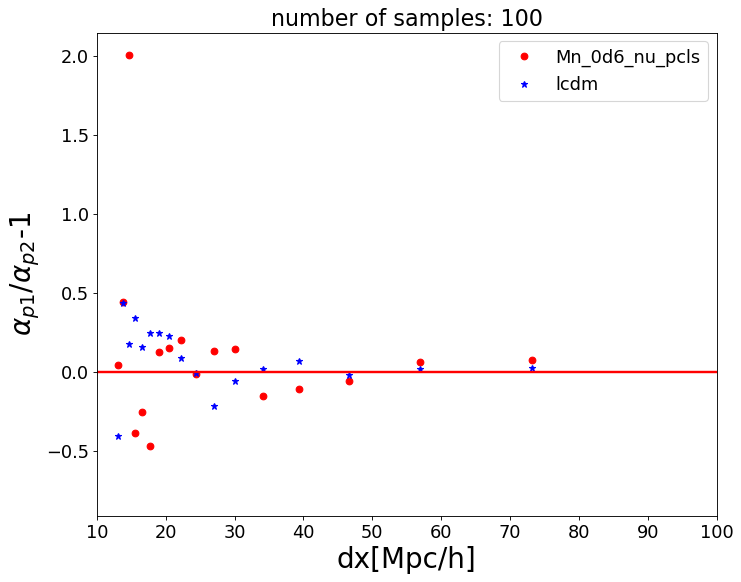

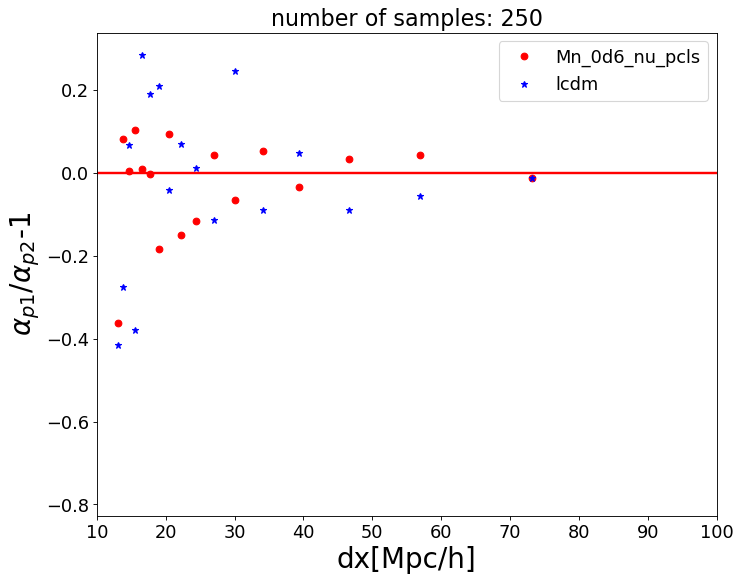

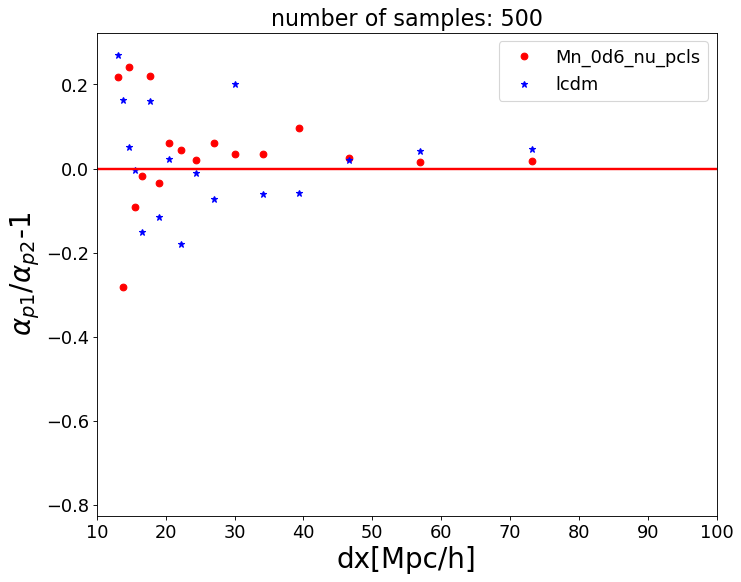

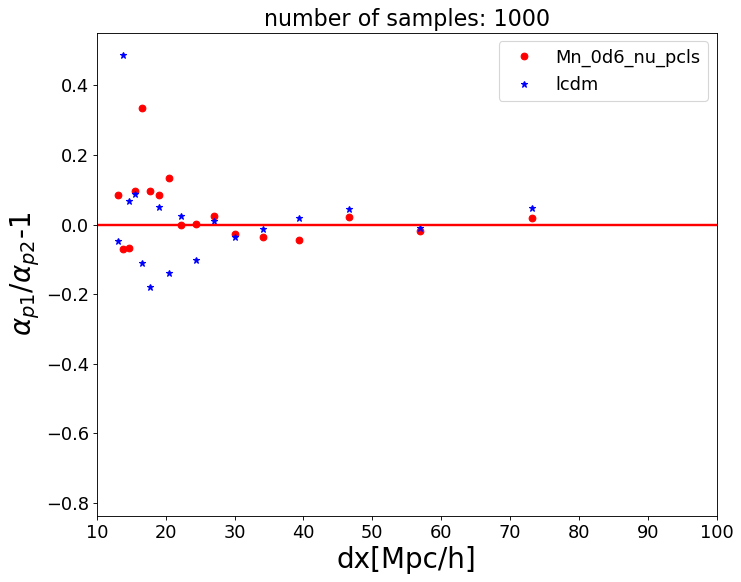

In [20]:




set_points = ["ro","b*"]

set_points2 = ["g^","ks"]
for number_smaples in [50, 100, 250, 500,1000]:
    from matplotlib.pyplot import figure
    figure(figsize=(10, 8), dpi=80)
    l = 0 
    for sim in ['Mn_0d6_nu_pcls','lcdm']:
        con1 = (data_alpha['simulation']==sim)
        con2 = (data_alpha['number_smaples']==number_smaples)
        x_p1 = data_alpha[con1 & con2]['dx']
        alpha_p1 = data_alpha[con1 & con2]['alpha_p1']
        std_alpha_p1 = data_alpha[con1 & con2]['std_alpha_p1']
        x_p2 = data_alpha[con1 & con2]['dx']
        alpha_p2 = data_alpha[con1 & con2]['alpha_p2']
        plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l], label=sim)
        plt.axhline(y=0, color='red', linewidth=2)

        plt.title("number of samples: "+ str(number_smaples), fontsize=20)
        plt.rcParams['xtick.labelsize']=16
        plt.rcParams['ytick.labelsize']=16
        plt.xlabel("dx[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
        plt.legend(fontsize=16)
        # plt.xscale('log')
        plt.xlim(10,100)
        # plt.yscale('symlog')
        data_alpha['number_smaples']==500
        l=l+1

# $\alpha$ histogram for a given $N_{grid}$

<ipython-input-22-6d078357fcce>:20: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values ":". Passing invalid values is deprecated since 3.4 and will become an error two minor releases later.
  plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")


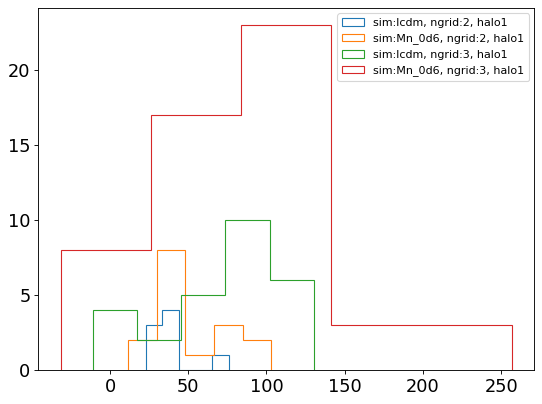

In [22]:
# from matplotlib.pyplot import figure
# figure(figsize=(8, 6), dpi=80)

# for ngrid in [2,3]:
#     boxsize=1024.;
#     mass_limit = 1.e14;
#     verbose="n"
#     alpha_all_h1=[]
#     alpha_all_h2=[]
#     for num in [3]: # the snapshot number start from high redshift
#         for sim in ['lcdm', 'Mn_0d6']:
#             for i in range(ngrid):
#                 for j in range(ngrid):
#                     for k in range(ngrid):
#                         sub_box_index=[i,j,k];
#                         alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
#                         alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

#             counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
#             plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
#             plt.legend()
#             ######
#             # counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
#             # plt.stairs(counts, bins, alpha=0.1, hatch='.',fill=True, label="sim:"+sim+", ngrid:"+str(ngrid)+", halo2")
#             plt.legend()
# # plt.